# CRISP-DM Phase 4: Modeling (Sirio-Libanes Clustering)

## Business framing

**Unit of analysis:** Each row in `X_pca` is a **patient × time window** (5 windows per patient; **1,925 rows** from prep). Clusters are **window-level phenotypes** — the same patient can fall in different clusters at different times unless you aggregate later.

K-Means partitions the **40-dimensional PCA space** into *k* groups using Euclidean distance after Phase 3 scaling and PCA.


In [7]:
import os
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')


## 1. Load Processed PCA Matrix
We load the perfectly scaled, 40-Dimension `X_pca.csv` generated from Phase 3. These 40 columns hold 95% of the information from the original 230 columns.

In [8]:
candidate_roots = [Path.cwd(), Path.cwd() / "clustering_sirio_covid_data_set"]


def _resolve_processed_dir(here: Path) -> Path:
    d = here / "data" / "processed" / "sirio"
    if d.is_dir():
        return d
    for root in candidate_roots:
        cand = root / "data" / "processed" / "sirio"
        if cand.is_dir():
            return cand
    return candidate_roots[0] / "data" / "processed" / "sirio"


data_dir = _resolve_processed_dir(Path.cwd())
meta_path = data_dir / "metadata.json"
if meta_path.exists():
    meta = json.loads(meta_path.read_text(encoding="utf-8"))
    print("metadata.json clustering_scope:", meta.get("clustering_scope"))
else:
    meta = {}
    print("metadata.json not found (optional); using CSV shape only.")

X_pca = pd.read_csv(data_dir / "X_pca.csv")
print(f"PCA matrix: {X_pca.shape} | loaded from {data_dir.resolve()}")

if meta.get("n_rows_feature_matrix") is not None:
    assert len(X_pca) == meta["n_rows_feature_matrix"], (
        f"Row count mismatch: CSV {len(X_pca)} vs metadata {meta['n_rows_feature_matrix']}"
    )


metadata.json clustering_scope: full_longitudinal_all_windows
PCA matrix: (1925, 40) | loaded from C:\Users\rahma\Desktop\machine learning project\clustering_sirio_covid_data_set\data\processed\sirio


## 2. Finding the Optimal 'K'
The 'K' in K-Means is the number of groups the AI should form. Does it form 2 groups, 3 groups, or 7 groups? We use two mathematical tests to find the optimal arrangement:
1. **Inertia (Elbow Method):** Measures how tightly packed each sphere is. We look for the "elbow" or kink in the line graph.
2. **Silhouette Score:** Measures how mathematically separated and distinct each sphere is from the other ones. (Higher is better, meaning the clusters are clean and untangled).

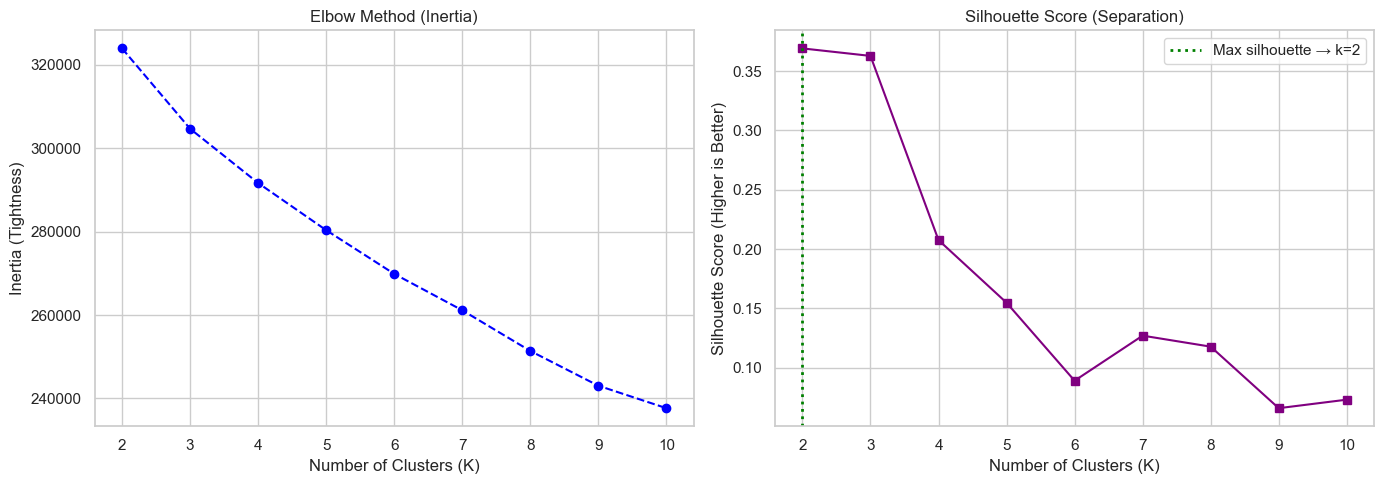

k sweep: {2: 0.3692, 3: 0.3628, 4: 0.2076, 5: 0.1547, 6: 0.089, 7: 0.127, 8: 0.1177, 9: 0.0658, 10: 0.073}
Best k by silhouette (in this sweep): 2


In [9]:
clusters_range = range(2, 11)
inertias = []
silhouette_scores = []
clusters_list = list(clusters_range)

pc_cols = [c for c in X_pca.columns if str(c).startswith("PC_")]
X_mat = X_pca[pc_cols].to_numpy()

for k in clusters_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_mat)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_mat, labels))

k_by_silhouette = clusters_list[int(np.argmax(silhouette_scores))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(clusters_list, inertias, marker='o', linestyle='--', color='blue')
ax1.set_title('Elbow Method (Inertia)')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (Tightness)')

ax2.plot(clusters_list, silhouette_scores, marker='s', linestyle='-', color='purple')
ax2.axvline(k_by_silhouette, color='green', linestyle=':', linewidth=2, label=f'Max silhouette → k={k_by_silhouette}')
ax2.set_title('Silhouette Score (Separation)')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score (Higher is Better)')
ax2.legend(loc='best')

plt.tight_layout()
plt.show()

print("k sweep:", dict(zip(clusters_list, [round(s, 4) for s in silhouette_scores])))
print(f"Best k by silhouette (in this sweep): {k_by_silhouette}")


## 3. Choosing `k`: five-supervisor deliberation

We **do not** pick `k` from “vibes” alone. Below is the explicit reasoning you would use in a review.

| Voice | Question | Lean |
|-------|----------|------|
| **1. Data / metrics** | What does the silhouette curve say on the grid we actually searched? | Prefer **argmax silhouette** on `k ∈ {2,…,10}` unless there is a strong override. Elbow is **ambiguous** (smooth curve); use it as context, not as a tie-breaker against a bad silhouette. |
| **2. Stability / health of solution** | Are clusters **balanced** or is one cluster a single point? | If one cluster has ~0 mass, the model is **not** delivering three clinical phenotypes—it is finding an outlier shell. That **invalidates** a forced `k=3` triage story. |
| **3. Domain / comms** | Do stakeholders want exactly three labels (e.g. low / medium / high acuity)? | Reasonable for **product copy**, but it must be **validated** on this matrix. If metrics and balance disagree, domain loses unless you change features, algorithm, or scope. |
| **4. Visualization** | “We can only plot 3D, so `k=3`?” | **No.** The 3D plot uses **PC₁–PC₃** for *display*. It does not fix the number of clusters—you can have six clusters and still plot in 3D. |
| **5. Deployment / governance** | What goes in the pickle? | Document **`k`**, variance retained in PCA, and row unit (**patient-window**). Changing `k` later without retraining breaks downstream consumers. |

**Bottom line:** The next cell fits K-Means at **`k = k_by_silhouette`** by default. If you need a fixed triage count for the business, set `STAKEHOLDER_K` (e.g. `3`) and **compare** metrics + cluster sizes to that baseline—do not assert three clinical states unless the partition supports it.


In [10]:
# Metrics-first default (matches the silhouette diagnostic above)
# Set to an int (e.g. 3) only if you accept worse separation / accept re-validation.
STAKEHOLDER_K = None

SELECTED_K = STAKEHOLDER_K if STAKEHOLDER_K is not None else k_by_silhouette
OPTIMAL_K = SELECTED_K

print(
    f"k_by_silhouette={k_by_silhouette} | "
    f"STAKEHOLDER_K={STAKEHOLDER_K} | fitting OPERATIONAL_K={OPTIMAL_K}"
)

if 'Predicted_Cluster' in X_pca.columns:
    X_pca = X_pca.drop(columns=['Predicted_Cluster'])

final_kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
final_labels = final_kmeans.fit_predict(X_mat)

X_pca['Predicted_Cluster'] = final_labels

print(f"K-Means fitted: {X_pca.shape[0]} longitudinal rows -> {OPTIMAL_K} clusters (patient-window units).")
print("Cluster sizes (check for degenerate single-point clusters):")
display(X_pca['Predicted_Cluster'].value_counts().sort_index())


k_by_silhouette=2 | STAKEHOLDER_K=None | fitting OPERATIONAL_K=2
K-Means fitted: 1925 longitudinal rows -> 2 clusters (patient-window units).
Cluster sizes (check for degenerate single-point clusters):


Predicted_Cluster
0    1713
1     212
Name: count, dtype: int64

## 4. 3D visualization (PC₁–PC₃ only)

Humans cannot read 40 dimensions at once. We **project** onto the three directions of largest variance (`PC_1`, `PC_2`, `PC_3`) for a scatter plot. **This is for exploration**, not a reason to set `k=3`.


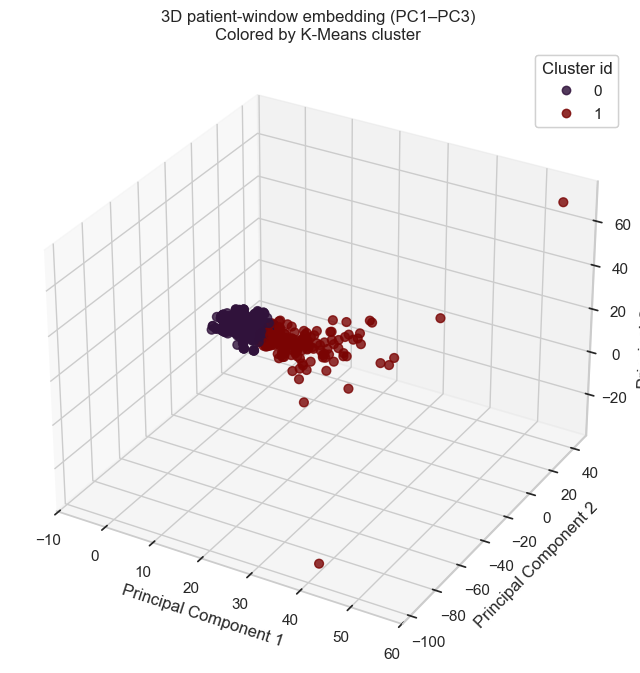

In [11]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca['PC_1'], X_pca['PC_2'], X_pca['PC_3'],
    c=X_pca['Predicted_Cluster'], cmap='turbo', s=40, alpha=0.8,
)

ax.set_title('3D patient-window embedding (PC1–PC3)\nColored by K-Means cluster')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

legend1 = ax.legend(*scatter.legend_elements(), title="Cluster id")
ax.add_artist(legend1)

plt.show()


## 5. Deployment export

We save the fitted K-Means object (trained on the PCA feature matrix **without** the label column). **Record `OPTIMAL_K` and preprocessing in release notes** so engineers know how many cluster centroids to expect.


In [12]:
models_dir = os.path.join('models')
os.makedirs(models_dir, exist_ok=True)

export_path = os.path.join(models_dir, 'sirio_kmeans_cluster_engine.pkl')

X_export = X_pca[pc_cols]
final_kmeans.fit(X_export)

joblib.dump(final_kmeans, export_path)

print(f"Success! Engine exported (k={OPTIMAL_K}) to: {os.path.abspath(export_path)}")


Success! Engine exported (k=2) to: C:\Users\rahma\Desktop\machine learning project\clustering_sirio_covid_data_set\models\sirio_kmeans_cluster_engine.pkl
